## Topic: Time Travel on Persistence in LangGraph

- Why Need:
    - Most useful for DEBUGGING & OBSERVABILITY

    - Example:    
        - "Why did the agent give that wrong answer?"             
        - Persistence lets you inspect EVERY intermediate state to trace exactly where things went wrong.

In [3]:
"""
- workflows:
    - topic ---> joke generate (LLM) ---> Explanation of joke (LLM)---> final response --> time travel(to got the past and crate a new but retrain the same workflow)

"""

'\n- workflows:\n    - topic ---> joke generate (LLM) ---> Explanation of joke (LLM)---> final response --> time travel(to got the past and crate a new but retrain the same workflow)\n\n'

In [4]:
# import necessary Library
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from dotenv import load_dotenv


c:\Users\kz\anaconda3\envs\GenAI\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


In [5]:
load_dotenv()

True

In [6]:
# Define the LLM for chat_node
llm =  ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [7]:
# 1. Define State
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [8]:
# 3. Define node (gen_joke)
def gen_joke(state: JokeState) -> dict:
    """ Generate a Joke based on Given topic """
    prompt = f"generate a joke on the topic {state['topic']}"

    response = llm.invoke(prompt).content

    return {
        "joke": response
    }


In [9]:
# 4. Define node (exp_joke)
def exp_joke(state: JokeState) -> dict:
    """ Explain a Joke based on Given Joke """
    prompt = f"Write an explanation on the joke {state['joke']}"

    response = llm.invoke(prompt).content

    return {
        "explanation": response
    }


In [10]:
# 2. Define graph
graph = StateGraph(JokeState)


# nodes
graph.add_node("generate_joke", gen_joke)
graph.add_node("explanation_joke", exp_joke)

# edges
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explanation_joke")
graph.add_edge("explanation_joke", END)



# 5. Define memory
memory = InMemorySaver()


# 6. compile the workflow
workflow = graph.compile(checkpointer=memory)


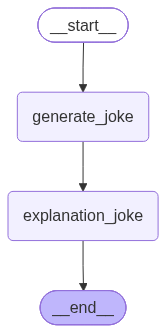

In [11]:
workflow

In [12]:
# 7. config with Thread_ID
config1 = {
    "configurable":{"thread_id": "1"}
}


# 8. execute the workflow
response = workflow.invoke({
    "topic": "Cricket"
    }, config= config1)


In [13]:
response

{'topic': 'Cricket',
 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!',
 'explanation': '**Why the joke works – a word‑play breakdown**\n\n| Element | What it means in the joke | What it means in everyday use |\n|---------|---------------------------|--------------------------------|\n| **Cricket team** | The “players” who are actually trying to hit the ball and get wickets. | A group of people playing cricket. |\n| **Ladder** | Something you climb to reach a higher place. | A tool used to get up to a higher level. |\n| **Wickets** | In cricket, the three stumps (and the two bails) that the bowler tries to hit. | The “goal” of the game – getting a batsman out. |\n| **High stakes** | The punchline’s double meaning. | An idiom meaning “great risk or importance.” |\n\n### 1. The set‑up\n\n> “Why did the cricket team bring a ladder to the match?”\n\nThe question sets up an absurd image: a cricket team carrying a ladder on

In [14]:
# Fetch the final state value of the workflow
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!', 'explanation': '**Why the joke works – a word‑play breakdown**\n\n| Element | What it means in the joke | What it means in everyday use |\n|---------|---------------------------|--------------------------------|\n| **Cricket team** | The “players” who are actually trying to hit the ball and get wickets. | A group of people playing cricket. |\n| **Ladder** | Something you climb to reach a higher place. | A tool used to get up to a higher level. |\n| **Wickets** | In cricket, the three stumps (and the two bails) that the bowler tries to hit. | The “goal” of the game – getting a batsman out. |\n| **High stakes** | The punchline’s double meaning. | An idiom meaning “great risk or importance.” |\n\n### 1. The set‑up\n\n> “Why did the cricket team bring a ladder to the match?”\n\nThe question sets up an absurd image: a cricket team c

In [15]:
# Get the all intermediate state values

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!', 'explanation': '**Why the joke works – a word‑play breakdown**\n\n| Element | What it means in the joke | What it means in everyday use |\n|---------|---------------------------|--------------------------------|\n| **Cricket team** | The “players” who are actually trying to hit the ball and get wickets. | A group of people playing cricket. |\n| **Ladder** | Something you climb to reach a higher place. | A tool used to get up to a higher level. |\n| **Wickets** | In cricket, the three stumps (and the two bails) that the bowler tries to hit. | The “goal” of the game – getting a batsman out. |\n| **High stakes** | The punchline’s double meaning. | An idiom meaning “great risk or importance.” |\n\n### 1. The set‑up\n\n> “Why did the cricket team bring a ladder to the match?”\n\nThe question sets up an absurd image: a cricket team 

- Key Note:
    - Here, this memory for thread_id': '1

In [16]:
# Now thread_id': '2'

config2 = {
    "configurable": {"thread_id": "2"}
}

# execute with thread_id : 2
response1 = workflow.invoke({
    "topic": "Football"
}, config= config2)


In [17]:
# response for thread_id 2: 
response1

{'topic': 'Football',
 'joke': 'Why did the football team go to the bank?\n\nBecause they heard they could get a *goal* in the *interest* rate! ⚽️🏦',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means in football | What it means in banking | How the joke blends them |\n|---------|---------------------------|--------------------------|--------------------------|\n| **Goal** | The thing you score to win a match. | A *financial goal* – something you’re aiming to achieve (e.g., “save for a house”). | The punchline says the team wants a *goal* in the *interest rate*, so it sounds like they’re trying to score a goal *inside* the bank’s interest‑rate chart. |\n| **Interest rate** | None (just a bank term). | The percentage a bank pays you on deposits or charges you on loans. | The joke uses the literal bank term “interest rate” to make the phrase sound like a place where a goal could be “inserted.” |\n| **Bank** | A place where money is kept. | A financia

In [18]:
# Fetch the final state response
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bank?\n\nBecause they heard they could get a *goal* in the *interest* rate! ⚽️🏦', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means in football | What it means in banking | How the joke blends them |\n|---------|---------------------------|--------------------------|--------------------------|\n| **Goal** | The thing you score to win a match. | A *financial goal* – something you’re aiming to achieve (e.g., “save for a house”). | The punchline says the team wants a *goal* in the *interest rate*, so it sounds like they’re trying to score a goal *inside* the bank’s interest‑rate chart. |\n| **Interest rate** | None (just a bank term). | The percentage a bank pays you on deposits or charges you on loans. | The joke uses the literal bank term “interest rate” to make the phrase sound like a place where a goal could be “inserted.” |\n| **Bank** | A place where money is

In [19]:
# Fetch the all intermediate state values
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bank?\n\nBecause they heard they could get a *goal* in the *interest* rate! ⚽️🏦', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means in football | What it means in banking | How the joke blends them |\n|---------|---------------------------|--------------------------|--------------------------|\n| **Goal** | The thing you score to win a match. | A *financial goal* – something you’re aiming to achieve (e.g., “save for a house”). | The punchline says the team wants a *goal* in the *interest rate*, so it sounds like they’re trying to score a goal *inside* the bank’s interest‑rate chart. |\n| **Interest rate** | None (just a bank term). | The percentage a bank pays you on deposits or charges you on loans. | The joke uses the literal bank term “interest rate” to make the phrase sound like a place where a goal could be “inserted.” |\n| **Bank** | A place where money i

### Introduce the Time Travel
- We go back to the past and create a new workflow.

- In this case,
    - we go the after the START node or when we get the topic

    - Step 1: first, we go to the those place where we get the topic
        - for doing these we copy the checkpoint_id

    - Step 2: 

In [ ]:
# Step 1: Now get the topic
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f1bf56e-f2b8-6571-8000-265ec907608f"}})

StateSnapshot(values={'topic': 'Football'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1bf56e-f2b8-6571-8000-265ec907608f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-10-03T18:19:12.589553+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf56e-f2b8-6570-bfff-757c4ccbba80'}}, tasks=(PregelTask(id='4ca6bfda-9343-7d24-e150-5e8ed474bbbe', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the football team go to the bank?\n\nBecause they heard they could get a *goal* in the *interest* rate! ⚽️🏦'}),), interrupts=())

- Key Note:
    - We get the topic name

In [ ]:
# Step 2: for new workflow
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f1bf56e-f2b8-6571-8000-265ec907608f"}})

{'topic': 'Football',
 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖',
 'explanation': ''}

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf583-c338-6353-8003-1d36b96bff71'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-10-03T18:28:31.323221+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf583-a8cc-6cf6-8002-2627015add3a'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖'}, next=('explanation_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf583-a8cc-6cf6-8002-2627015add3a'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-03T18:28:28.5

### Updating State

In [23]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f1bf56e-f2b8-6571-8000-265ec907608f", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bf5e0-d105-62de-8001-52ae0faa8958'}}

In [24]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf5e0-d105-62de-8001-52ae0faa8958'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-10-03T19:10:09.220067+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf56e-f2b8-6571-8000-265ec907608f'}}, tasks=(PregelTask(id='42d15b29-fda0-dc4d-dd58-7470e116a942', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf583-c338-6353-8003-1d36b96bff71'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}

In [25]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f1bf5e0-d105-62de-8001-52ae0faa8958"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it felt it was always being *stuffed* with expectations and never got a chance to *crisp* up its own life!',
 'explanation': '**Why the samosa went to therapy?**  \nBecause it felt it was always being *stuffed* with expectations and never got a chance to *crisp* up its own life!\n\n---\n\n### 1. The absurd premise\n\nThe joke starts with a classic “food‑in‑human‑situation” set‑up: a samosa (a fried, triangular pastry filled with spiced vegetables or meat) is anthropomorphized and given a human problem—needing therapy. The sheer absurdity of a snack going to a therapist is the first layer of humor. It’s a playful “what if” that immediately signals that the punchline will be a pun or a double‑meaning twist.\n\n---\n\n### 2. The double‑meaning of “stuffed”\n\n- **Literal sense**: A samosa is literally *stuffed*—its dough is filled with a savory mixture before it’s sealed and fried.  \n- **Figurative sense**: In eve

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it felt it was always being *stuffed* with expectations and never got a chance to *crisp* up its own life!', 'explanation': '**Why the samosa went to therapy?**  \nBecause it felt it was always being *stuffed* with expectations and never got a chance to *crisp* up its own life!\n\n---\n\n### 1. The absurd premise\n\nThe joke starts with a classic “food‑in‑human‑situation” set‑up: a samosa (a fried, triangular pastry filled with spiced vegetables or meat) is anthropomorphized and given a human problem—needing therapy. The sheer absurdity of a snack going to a therapist is the first layer of humor. It’s a playful “what if” that immediately signals that the punchline will be a pun or a double‑meaning twist.\n\n---\n\n### 2. The double‑meaning of “stuffed”\n\n- **Literal sense**: A samosa is literally *stuffed*—its dough is filled with a savory mixture before it’s sealed and fried.  \n- **Figura